In [3]:
!pip install prophet statsmodels

In [4]:
# ==========================================================
# Cell 1 : Import Libraries & Load Dataset
# ==========================================================

import os
import warnings
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from statsmodels.tsa.holtwinters import ExponentialSmoothing

warnings.filterwarnings("ignore")

# Create output folders
os.makedirs("../images", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# Load cleaned dataset
df = pd.read_csv(
    "../data/processed/retail_clean.csv",
    parse_dates=["Order_Date"]
)

print("Dataset Loaded Successfully")
print("Shape:", df.shape)

display(df.head())

Dataset Loaded Successfully
Shape: (20000, 13)


,Order_ID,Order_Date,Customer_ID,Product_ID,Category,Region,Quantity,Unit_Price,Discount,Sub_Category,Sales,Cost,Profit
0,ORD100000,2024-05-10,CUST01487,PROD0029,Beauty,Central,7,29.35,0.26,Skincare,152.03,98.82,53.21
1,ORD100001,2024-11-10,CUST00042,PROD0026,Grocery,North,7,247.81,0.07,Snacks,1613.24,1048.61,564.63
2,ORD100002,2022-05-02,CUST01197,PROD0070,Beauty,East,1,365.99,0.09,Makeup,333.05,216.48,116.57
3,ORD100003,2023-04-12,CUST00679,PROD0011,Beauty,South,2,269.54,0.16,Haircare,452.83,294.34,158.49
4,ORD100004,2022-11-27,CUST01274,PROD0100,Grocery,West,5,163.63,0.13,Dairy,711.79,462.66,249.13


In [5]:
# ==========================================================
# Cell 2 : Aggregate Daily Sales
# ==========================================================

daily_sales = (
    df.groupby("Order_Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["ds", "y"]

print(daily_sales.head())

          ds         y
0 2022-01-01  25485.07
1 2022-01-02  14665.14
2 2022-01-03  19671.26
3 2022-01-04  21385.45
4 2022-01-05  14551.41


In [6]:
# ==========================================================
# Cell 3 : Prophet Forecast
# ==========================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(daily_sales)

future = model.make_future_dataframe(periods=90)

forecast = model.predict(future)

print("Forecast Generated Successfully")

14:29:43 - cmdstanpy - INFO - Chain [1] start processing
14:29:44 - cmdstanpy - INFO - Chain [1] done processing


Forecast Generated Successfully


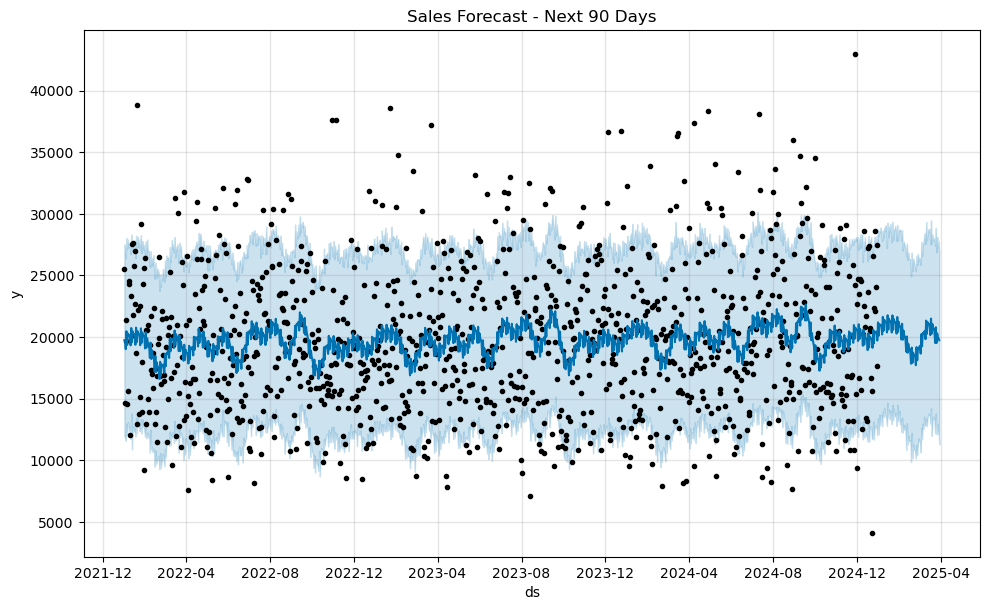

In [7]:
# ==========================================================
# Cell 4 : Forecast Plot
# ==========================================================

fig = model.plot(forecast)

plt.title("Sales Forecast - Next 90 Days")

plt.savefig(
    "../images/sales_forecast_prophet.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

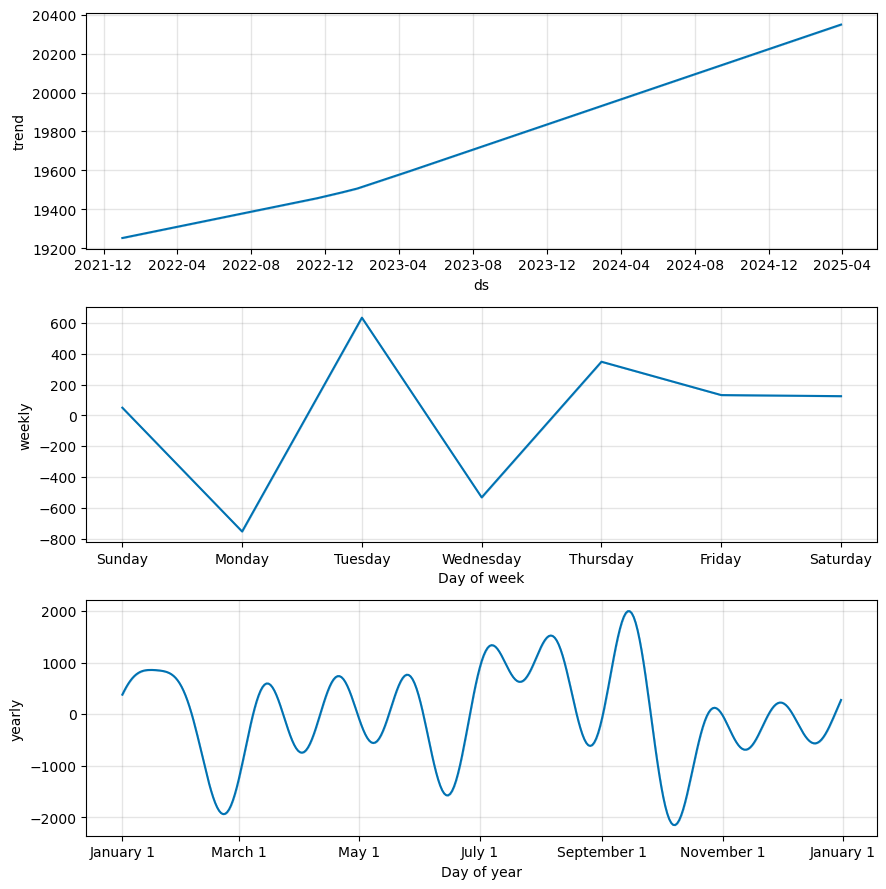

In [8]:
# ==========================================================
# Cell 5 : Trend & Seasonality
# ==========================================================

fig = model.plot_components(forecast)

plt.savefig(
    "../images/sales_forecast_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

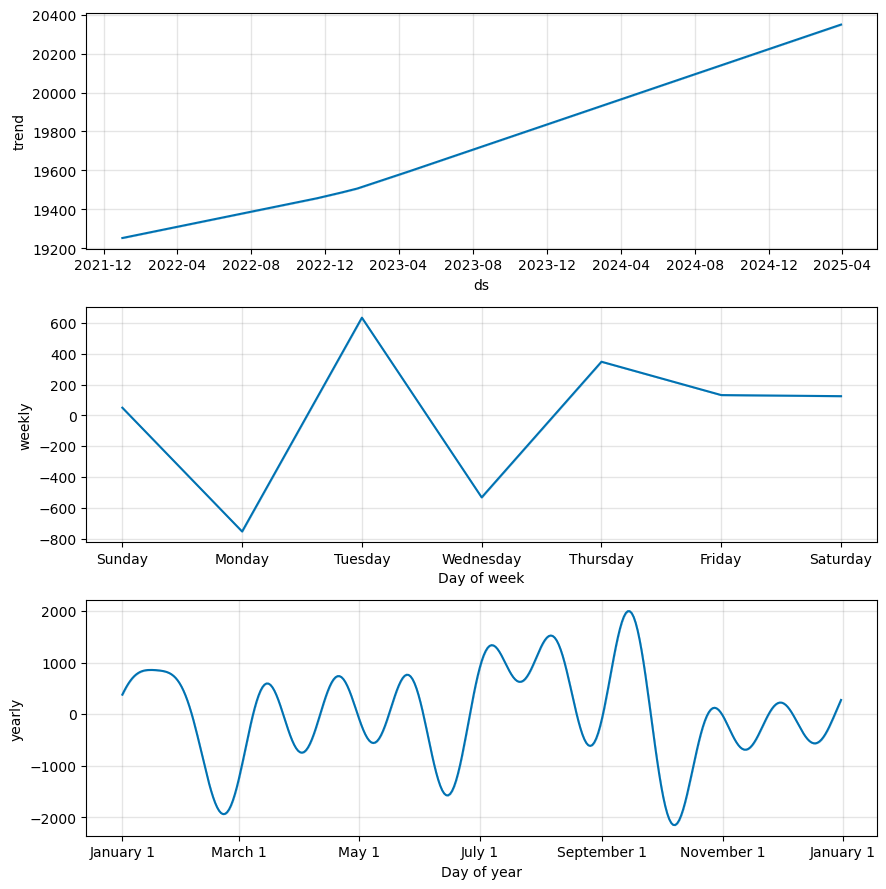

In [9]:
# ==========================================================
# Cell 5 : Trend & Seasonality
# ==========================================================

fig = model.plot_components(forecast)

plt.savefig(
    "../images/sales_forecast_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
# ==========================================================
# Cell 6 : Save Forecast
# ==========================================================

forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].to_csv(
    "../reports/sales_forecast.csv",
    index=False
)

print("Forecast Saved Successfully")

Forecast Saved Successfully


In [11]:
# ==========================================================
# Cell 7 : Holt-Winters Benchmark
# ==========================================================

monthly = (
    daily_sales
    .set_index("ds")
    .resample("ME")
    .sum()
)

hw_model = ExponentialSmoothing(
    monthly["y"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_forecast = hw_model.forecast(6)

print("Next 6 Months Forecast")

display(hw_forecast)

Next 6 Months Forecast


2025-01-31    626834.145395
2025-02-28    552687.733102
2025-03-31    631526.470484
2025-04-30    618245.581711
2025-05-31    631730.865412
2025-06-30    568963.649171
Freq: ME, dtype: float64

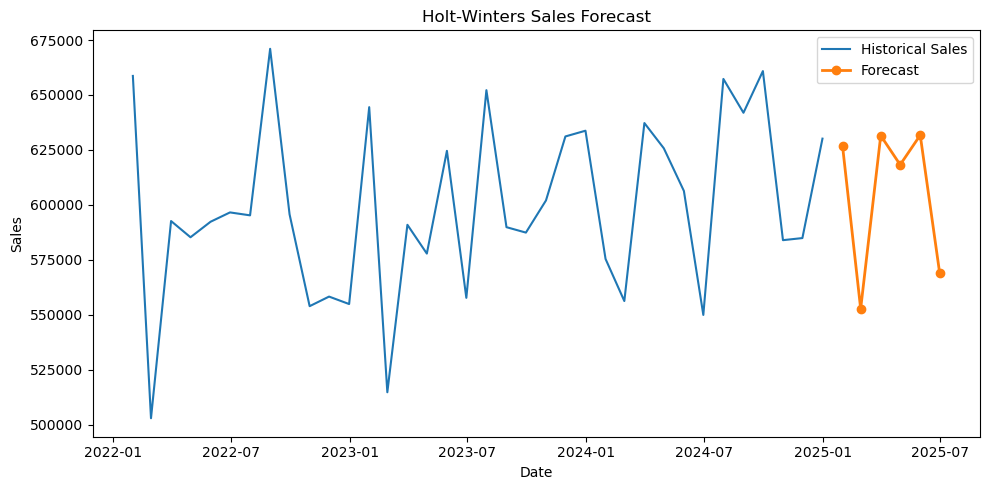

In [12]:
# ==========================================================
# Cell 8 : Holt-Winters Forecast Plot
# ==========================================================

plt.figure(figsize=(10,5))

plt.plot(
    monthly.index,
    monthly["y"],
    label="Historical Sales"
)

plt.plot(
    hw_forecast.index,
    hw_forecast.values,
    marker="o",
    linewidth=2,
    label="Forecast"
)

plt.title("Holt-Winters Sales Forecast")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../images/holt_winters_forecast.png",
    dpi=300
)

plt.show()